```text
LGD model
├── Import & Setup
├── Limitation
└── LGD estimation
    ├── Explore
    ├── Fit & Evaluate
    ├── Transform
    └── Export
```

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.feature_engineering import create_target_def12
from src.metrics import my_regression_metrics
from src.modelling import apply_pipe, fit_lgd, transform_lgd
from src.plots import compare_lgd_distributions, explore_variable, variable_vs_lgd 
from src.preprocessing import my_input_load, my_time_split, ReplaceMinusOne

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# import pipeline

import joblib
pipeline = joblib.load("../models/PIPELINE_ver_011_cal_shift-test.pkl")

In [4]:
# load input file

full_dataset = my_input_load(2019, 2020)

# create def12

full_dataset, dr_summary = create_target_def12(full_dataset)

# split train/test

windows = {"train": (2019, 2019), "test":  (2020, 2020)}

splits = my_time_split(full_dataset, "LoanYear", windows)

ds_trai = splits["train"]["df"]
ds_test = splits["test"]["df"]

LoanDate range:     2019-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2020-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2019-04-26 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2019,28487,4879,0.171271
2020,19959,2294,0.114936



SPLIT SUMMARY

TRAIN
Years        : 2019 - 2019
Shape (X, y) : (28487, 105), (28487,)

LoanYear distribution
LoanYear
2019    28487
Name: count, dtype: int64

Default rate : 0.1713
------------------------------------------------------------

TEST
Years        : 2020 - 2020
Shape (X, y) : (19959, 105), (19959,)

LoanYear distribution
LoanYear
2020    19959
Name: count, dtype: int64

Default rate : 0.1149
------------------------------------------------------------


In [5]:
# apply PD pipeline

ds_trai  = apply_pipe(ds_trai , pipeline, calculate_el=False, sensitivity_lgd=False)
ds_test  = apply_pipe(ds_test , pipeline, calculate_el=False, sensitivity_lgd=False)

EmploymentStatus: replacing 28,487 values of -1 with NaN
MaritalStatus: replacing 28,487 values of -1 with NaN
OccupationArea: replacing 28,487 values of -1 with NaN
UseOfLoan: replacing 28,487 values of -1 with NaN
EmploymentStatus: replacing 19,959 values of -1 with NaN
MaritalStatus: replacing 19,959 values of -1 with NaN
OccupationArea: replacing 19,959 values of -1 with NaN
UseOfLoan: replacing 19,959 values of -1 with NaN


#### Limitation

Analysis reveals a structural change in the LossGivenDefault variable across loan origination years. While the period **2019–2020** contains zero-loss observations (full-recoveries), earlier and later years show higher and constrained LGD values, suggesting differences in the underlying target definition or calculation methodology. Since the objective of this project is to demonstrate a modular LGD estimation rather than validate the dataset itself, LossGivenDefault is treated as the observed target variable, and the LGD models are developed on the 2019–2020 period, where the target behaves consistently.

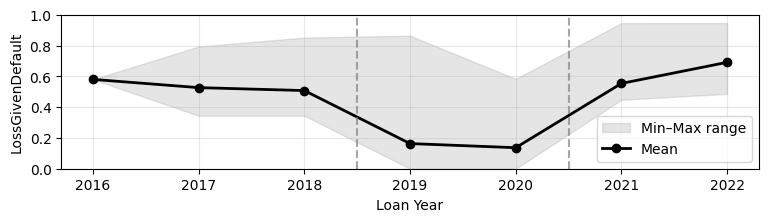

In [6]:
# explore "LossGivenDefault" across years

explore_variable(variable="LossGivenDefault", yr_start=2016, yr_end=2022, breaks=[2018.5, 2020.5])

## LGD estimation

#### Explore

In [7]:
columns_to_use = [
    "Age",
    "Gender",
    "Amount",
    "Interest",
    "LoanDuration",
    "Education",
    "EmploymentDurationCurrentEmployer",
    "HomeOwnershipType",
    "IncomeTotal",
    "ExistingLiabilities",
    "LiabilitiesTotal",
    "CreditScoreEeMini",
    "NoOfPreviousLoansBeforeLoan",
    "AmountOfPreviousLoansBeforeLoan",
    "PreviousRepaymentsBeforeLoan"
]

for variable in columns_to_use:
    if ds_trai[variable].nunique() <= 20:
        print(variable)
        variable_vs_lgd(ds_trai, variable)

Gender


,Gender,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,0.000000,3486,0.224,1950,1536,55.938
1,1.000000,1393,0.067,1234,159,88.586


LoanDuration


,LoanDuration,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,6,7,0.059,6,1,85.714
1,9,12,0.000,12,0,100.000
2,12,20,0.158,13,7,65.000
3,18,29,0.033,27,2,93.103
4,24,45,0.150,31,14,68.889
5,30,41,0.127,31,10,75.610
6,36,2007,0.183,1261,746,62.830
7,48,197,0.197,119,78,60.406
8,60,2521,0.179,1684,837,66.799


Education


...

,EmploymentDurationCurrentEmployer,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,MoreThan5Years,1234,0.192,767,467,62.156
1,Other,248,0.159,172,76,69.355
2,Retiree,277,0.198,175,102,63.177
3,TrialPeriod,17,0.375,5,12,29.412
4,UpTo1Year,1343,0.186,870,473,64.780
5,UpTo2Years,59,0.242,30,29,50.847
6,UpTo3Years,44,0.252,21,23,47.727
7,UpTo4Years,13,0.259,6,7,46.154
8,UpTo5Years,1644,0.158,1138,506,69.221


HomeOwnershipType


,HomeOwnershipType,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,1.000000,1774,0.191,1120,654,63.134
1,2.000000,1108,0.176,737,371,66.516
2,3.000000,1149,0.158,802,347,69.800
3,4.000000,24,0.271,11,13,45.833
4,5.000000,58,0.228,33,25,56.897
5,6.000000,14,0.338,5,9,35.714
6,7.000000,28,0.338,9,19,32.143
7,8.000000,212,0.193,118,94,55.660
8,9.000000,5,0.323,1,4,20.000
9,10.000000,507,0.165,348,159,68.639


CreditScoreEeMini


,CreditScoreEeMini,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,500.000000,21,0.118,16,5,76.190
1,600.000000,244,0.138,173,71,70.902
2,700.000000,258,0.172,176,82,68.217
3,800.000000,601,0.164,419,182,69.717
4,900.000000,393,0.187,257,136,65.394
5,1000.000000,3362,0.185,2143,1219,63.742


#### Fit & Evaluate

LGD estimation method: univariate
Feature: Amount
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.197
RMSE        : 0.230
CORR        : 0.272
R2          : 0.068
----------------------------------------


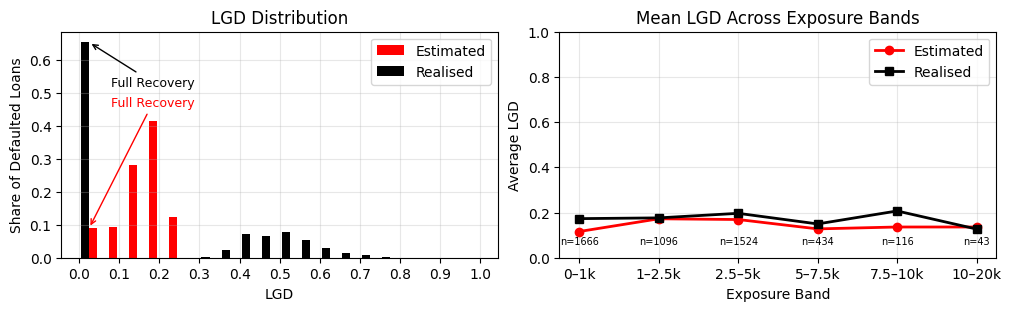

,Dataset,MAE,RMSE,CORR,R2,Variable,Method
0,TRAIN,0.197262,0.22993,0.272266,0.068352,Amount,univariate


In [8]:
# loop

experiments = [
    #("historical_avg", None),
    #("univariate", "Gender"),
    #("univariate", "Age"),
    ("univariate", "Amount"),
    #("univariate", "Interest"),
    #("univariate", "Education"),
    #("univariate", "LoanDuration"),
    #("univariate", "HomeOwnershipType"),
    #("univariate", "CreditScoreEeMini"),
    #("univariate", "EmploymentDurationCurrentEmployer"),
]

metrics = []

for method, variable in experiments:

    # fit: estimate lgds on train dataset
    
    lgd_model = fit_lgd(ds_trai, method="univariate", one_variable="Amount")
    ds_trai   = transform_lgd(ds_trai, lgd_model)

    # evaluate:
    # - calculate metrics
    # - compare estimated/realised distributions

    metrics_1 = my_regression_metrics(ds_trai["LossGivenDefault"], ds_trai["LGD"], dataset_name="TRAIN", verbose=True)   
    metrics_1["Variable"] = variable
    metrics_1["Method"]   = method
    metrics.append(metrics_1)
    compare_lgd_distributions(ds_trai)

metrics = pd.DataFrame(metrics)
display(metrics.sort_values(by=["Dataset", "CORR"], ascending=[False, False]))



#### Transform

----------------------------------------
TEST
----------------------------------------
MAE         : 0.188
RMSE        : 0.238
CORR        : 0.004
R2          : -0.126
----------------------------------------


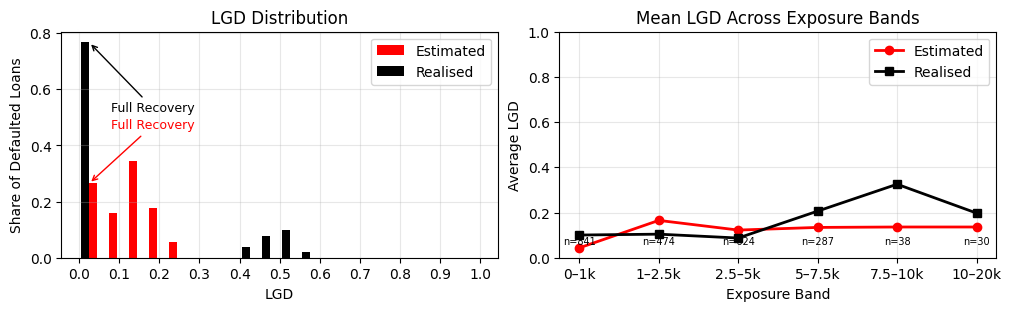

In [9]:
# transform: estimate lgds on oot dataset

ds_test   = transform_lgd(ds_test, lgd_model)

# evaluate:
# - calculate metrics
# - compare estimated/realised distributions

metrics_1 = my_regression_metrics(ds_test["LossGivenDefault"], ds_test["LGD"], dataset_name="TEST", verbose=True)   
compare_lgd_distributions(ds_test)

#### Export

In [ ]:
#joblib.dump(lgd_model, "../models/lgd_model_Amount.pkl")

['../models/lgd_model_Amount.pkl']